In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel("df_resultado_54_57_legislaturas.xlsx", sheet_name="Sheet1")

df = df[
    [
        "id_dep",
        "theil",
        "n_props",
        "norm_freq",
        "n_props_log",
        "norm_props_log",
        "percent_national",
        "legislatura",
        "gmm_cluster",
    ]
]

df = df[df["legislatura"] != "Todas"]

cluster_map = {
    0: "Generalista Regional Produtivo",
    1: "Generalista Nacional Produtivo",
    2: "Generalista Regional de Baixa Produtividade",
    3: "Nacional Misto",
    4: "Especialista de Baixa Produtividade",
}

# Tendências

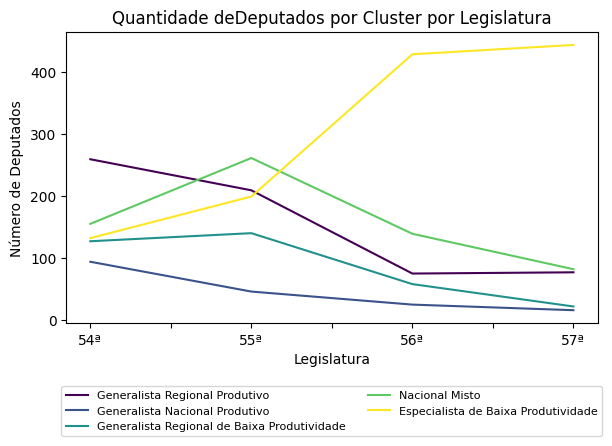

In [15]:
df_g_legis = df.groupby(["legislatura", "gmm_cluster"]).agg({"id_dep": "count"})
df_g_legis = df_g_legis.reset_index()

# Pivot the data for area plot
df_pivot = df_g_legis.pivot(index="legislatura", columns="gmm_cluster", values="id_dep")

# Create area plot
df_pivot.plot(kind="line", stacked=False, legend=False, cmap='viridis')
plt.legend(labels=list(cluster_map.values()), bbox_to_anchor=(0.5, -0.3), loc='center', ncol=2, fontsize=8)
plt.xlabel("Legislatura")
plt.ylabel("Número de Deputados")
plt.title("Quantidade deDeputados por Cluster por Legislatura")
plt.tight_layout()
plt.show()

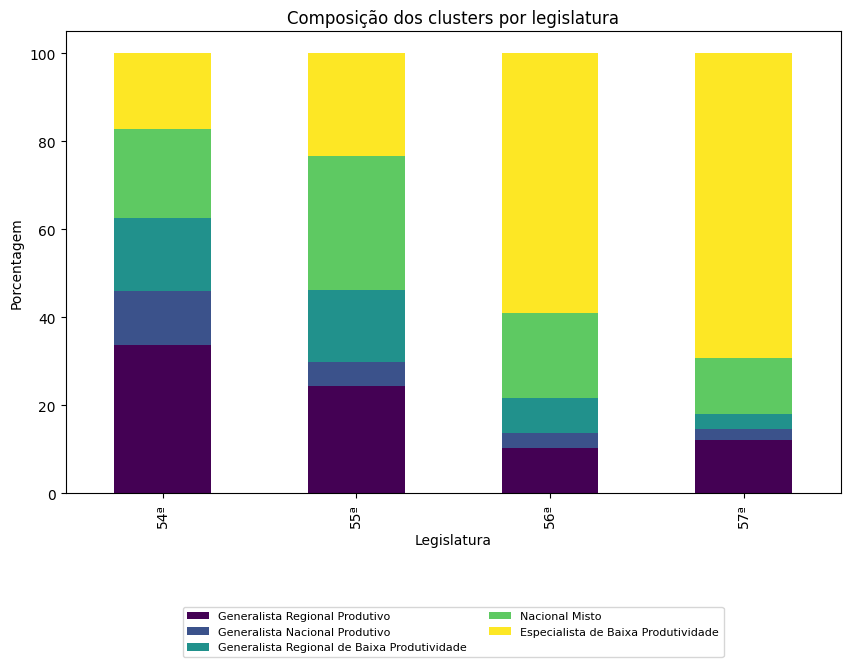

In [21]:
# Create a stacked bar chart showing cluster composition by legislature
cluster_by_legislature = (
    pd.crosstab(df["legislatura"], df["gmm_cluster"], normalize="index") * 100
)
cluster_by_legislature.plot(kind="bar", stacked=True, figsize=(10, 6), cmap='viridis')
plt.title("Composição dos clusters por legislatura")
plt.xlabel("Legislatura")
plt.ylabel("Porcentagem")
plt.legend(labels=list(cluster_map.values()), bbox_to_anchor=(0.5, -0.3), loc='center', ncol=2, fontsize=8)
plt.show()

# Características dos clusters

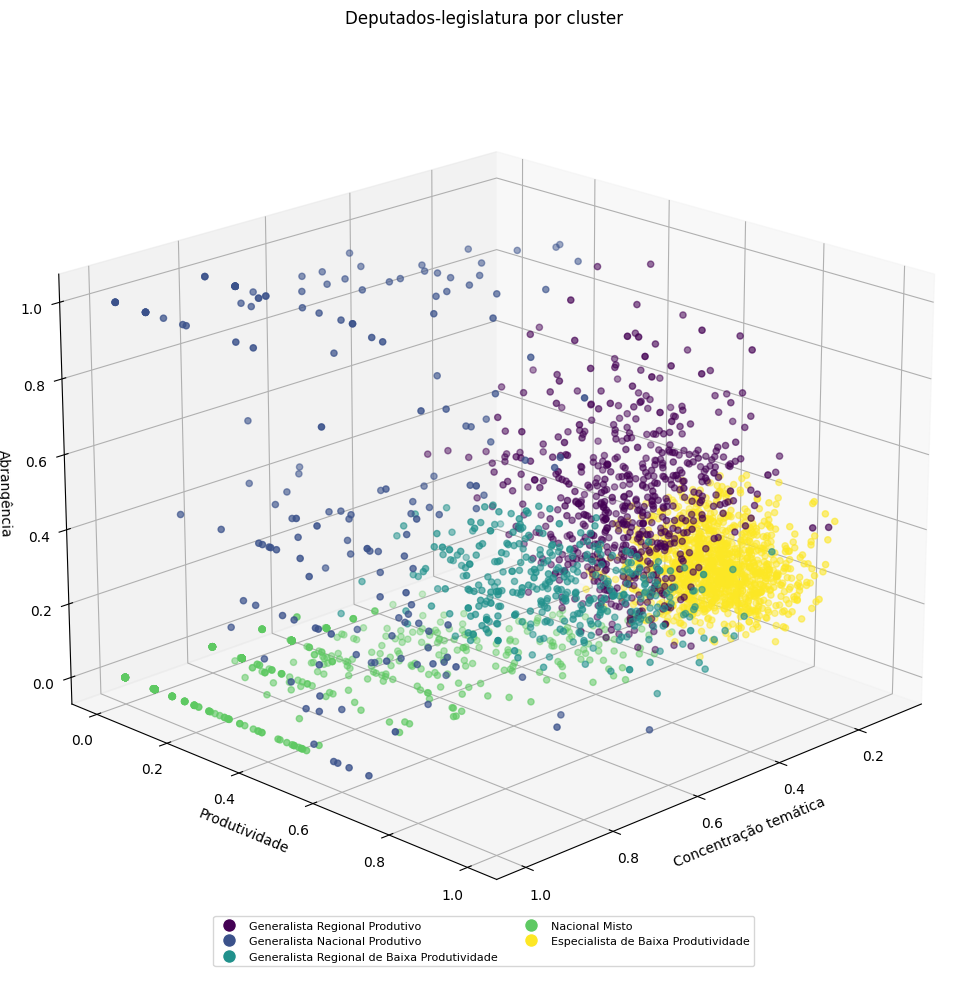

In [14]:
import matplotlib.pyplot as plt
import numpy as np

x_label = "theil"
y_label = "norm_props_log"
z_label = "percent_national"
k_value = 5

# Create figure and 3D plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection="3d")

# Create scatter plot with proper color mapping
scatter = ax.scatter(
    df[x_label],
    df[y_label],
    df[z_label],
    c=df["gmm_cluster"],
    cmap='viridis'
)

# Set labels
ax.set_xlabel("Concentração temática")
ax.set_ylabel("Produtividade")
ax.set_zlabel("Abrangência")

# Create legend with proper handles and labels
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.viridis(i/4), markersize=10) 
           for i in range(5)]
legend = ax.legend(
    handles=handles,
    labels=list(cluster_map.values()),
    bbox_to_anchor=(0.5, 0.04),
    loc="center",
    ncol=2,
    fontsize=8
)

# Set view angle
ax.view_init(elev=20, azim=45)
ax.set_title(f"Deputados-legislatura por cluster")

plt.tight_layout()
plt.show()

In [ ]:
# Pivot the data for area plot
df_pivot = df_g_legis.pivot(index="legislatura", columns="gmm_cluster", values="id_dep")

# Create area plot
df_pivot.plot(kind="line", stacked=False)
plt.xlabel("Legislatura")
plt.ylabel("Número de Deputados")
plt.title("Distribuição de Deputados por Cluster por Legislatura")
plt.show()

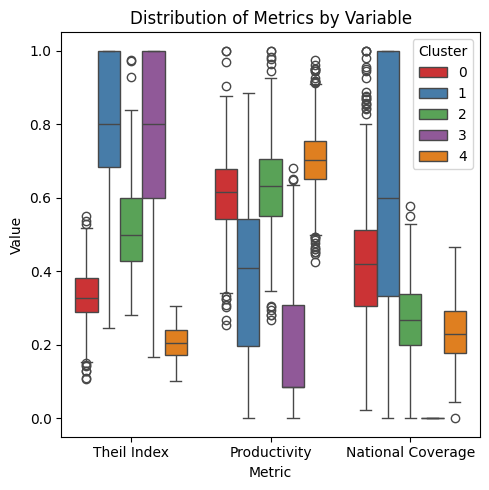

In [121]:
plt.figure(figsize=(5, 5))
sns.boxplot(
    x="variable",
    y="value",
    hue="gmm_cluster",
    palette="Set1",
    data=pd.melt(
        df,
        id_vars=["gmm_cluster"],
        value_vars=["theil", "norm_props_log", "percent_national"],
        var_name="variable",
        value_name="value",
    ),
)
plt.title("Distribution of Metrics by Variable")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.legend(title="Cluster")
plt.xticks(ticks=[0, 1, 2], labels=["Theil Index", "Productivity", "National Coverage"])
plt.tight_layout()

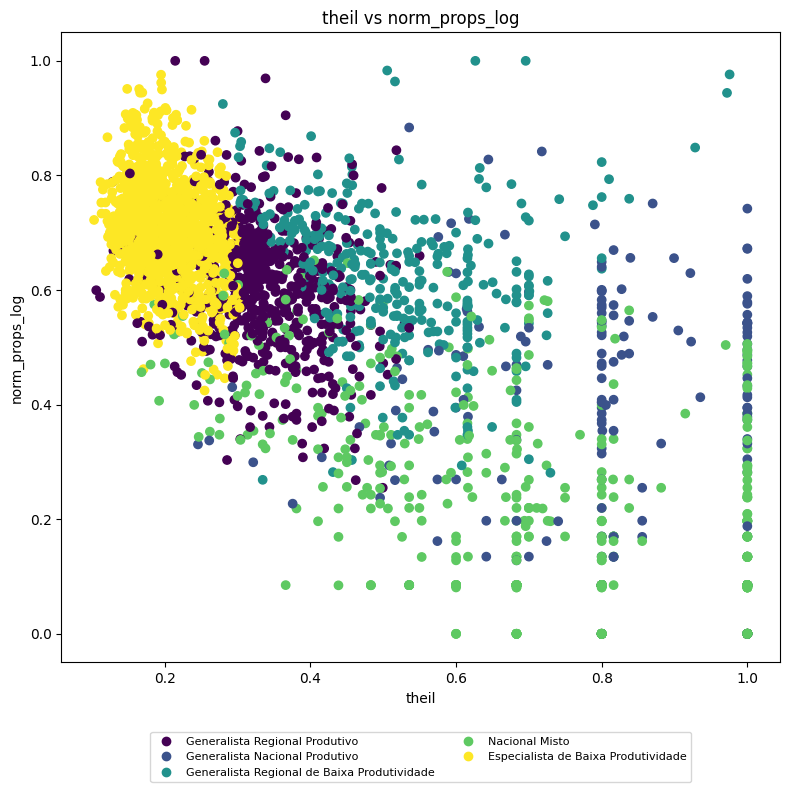

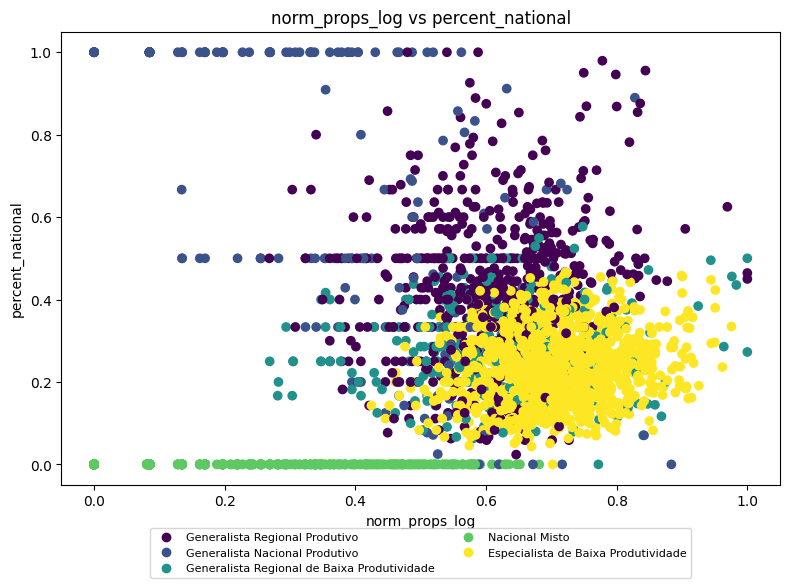

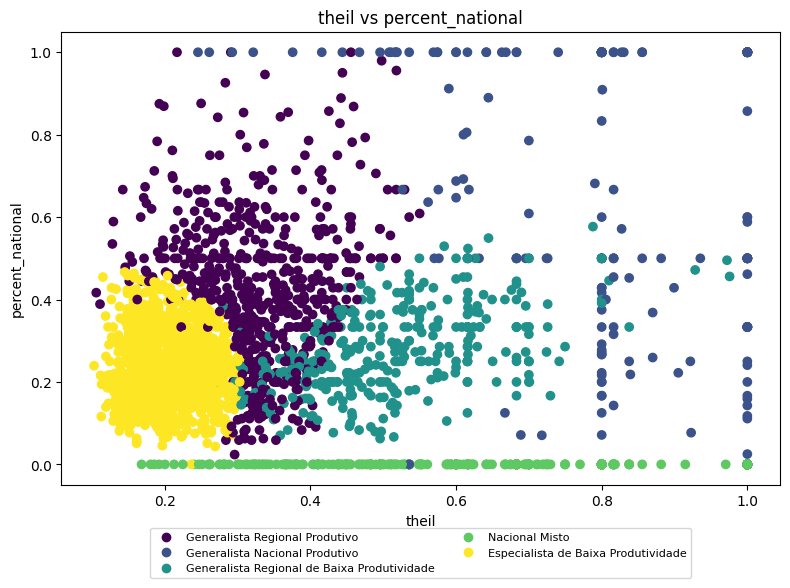

In [120]:
# Create first scatter plot
plt.figure(figsize=(8, 8
))
scatter1 = plt.scatter(df[x_label], df[y_label], c=df["gmm_cluster"], cmap='viridis')
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(f"{x_label} vs {y_label}")

# Create legend for first plot
handles, labels = scatter1.legend_elements()
plt.legend(handles, list(cluster_map.values()), 
          bbox_to_anchor=(0.5, -.15),
          ncol=2,
          loc='center',
          fontsize=8)

plt.tight_layout()
plt.show()

# Create second scatter plot
plt.figure(figsize=(8, 6))  
scatter2 = plt.scatter(df[y_label], df[z_label], c=df["gmm_cluster"], cmap='viridis')
plt.xlabel(y_label)
plt.ylabel(z_label)
plt.title(f"{y_label} vs {z_label}")

# Create legend for second plot
handles, labels = scatter2.legend_elements()
plt.legend(handles, list(cluster_map.values()), 
          bbox_to_anchor=(0.5, -.15),
          ncol=2,
          loc='center',
          fontsize=8)

plt.tight_layout()
plt.show()

# Create second scatter plot
plt.figure(figsize=(8, 6))  
scatter2 = plt.scatter(df[x_label], df[z_label], c=df["gmm_cluster"], cmap='viridis')
plt.xlabel(x_label)
plt.ylabel(z_label)
plt.title(f"{x_label} vs {z_label}")

# Create legend for second plot
handles, labels = scatter2.legend_elements()
plt.legend(handles, list(cluster_map.values()), 
          bbox_to_anchor=(0.5, -.15),
          ncol=2,
          loc='center',
          fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# Create box plots for key variables across clusters
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Distribution of Variables Across Clusters")

# Theil Index distribution
sns.boxplot(data=df, x="gmm_cluster", y="theil", ax=axes[0, 0])
axes[0, 0].set_title("Theil Index by Cluster")
axes[0, 0].set_xlabel("Cluster")
axes[0, 0].set_ylabel("Theil Index")

# Number of proposals distribution
sns.boxplot(data=df, x="gmm_cluster", y="n_props", ax=axes[0, 1])
axes[0, 1].set_title("Number of Proposals by Cluster")
axes[0, 1].set_xlabel("Cluster")
axes[0, 1].set_ylabel("Number of Proposals")

# Normalized frequency distribution
sns.boxplot(data=df, x="gmm_cluster", y="norm_freq", ax=axes[1, 0])
axes[1, 0].set_title("Normalized Frequency by Cluster")
axes[1, 0].set_xlabel("Cluster")
axes[1, 0].set_ylabel("Normalized Frequency")

# Percentage of national proposals
sns.boxplot(data=df, x="gmm_cluster", y="percent_national", ax=axes[1, 1])
axes[1, 1].set_title("Percentage of National Proposals by Cluster")
axes[1, 1].set_xlabel("Cluster")
axes[1, 1].set_ylabel("Percentage National")

plt.tight_layout()
plt.show()

# Create scatter plots to show relationships between variables by cluster
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="theil", y="n_props", hue="gmm_cluster", style="gmm_cluster")
plt.title("Theil Index vs Number of Proposals by Cluster")
plt.xlabel("Theil Index")
plt.ylabel("Number of Proposals")
plt.show()

# Additional scatter plot for normalized frequency vs percentage national
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, x="norm_freq", y="percent_national", hue="gmm_cluster", style="gmm_cluster"
)
plt.title("Normalized Frequency vs Percentage National by Cluster")
plt.xlabel("Normalized Frequency")
plt.ylabel("Percentage National")
plt.show()

# Outras

In [ ]:
# Create correlation matrix and plot
correlation_vars = ["theil", "norm_props_log", "percent_national"]
corr_matrix = df[correlation_vars].corr()

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1, center=0)
plt.title("Correlation Matrix of Variables")
plt.tight_layout()
plt.show()

In [ ]:
# Scatter plots with cluster coloring
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="theil", y="n_props", hue="gmm_cluster", style="gmm_cluster")
plt.title("Theil Index vs Number of Proposals by Cluster")
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df, x="norm_freq", y="percent_national", hue="gmm_cluster", style="gmm_cluster"
)
plt.title("Normalized Frequency vs Percentage National by Cluster")
plt.show()